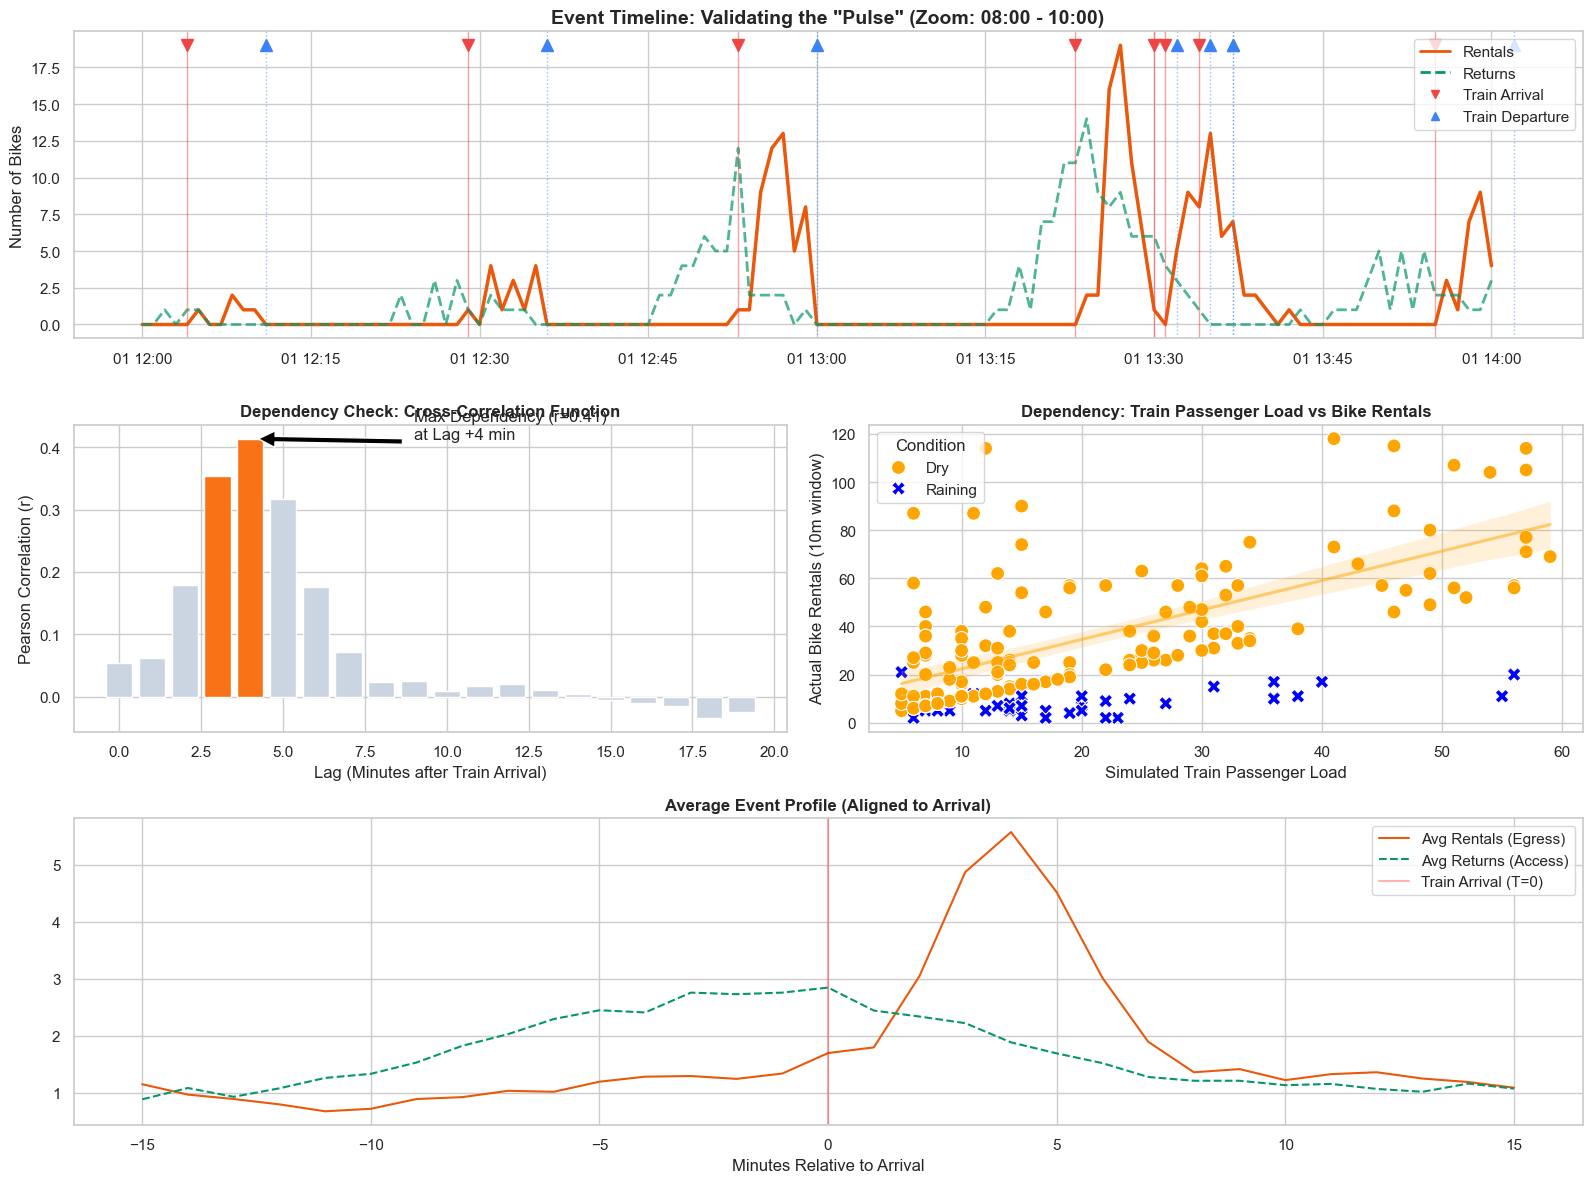

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, pearsonr
from matplotlib.patches import Rectangle

# ==========================================
# 1. SIMULATION ENGINE (Data Generation)
# ==========================================
np.random.seed(42)

def generate_simulation_data(hours=48):
    """Generates realistic Train, Weather, and Bike data."""
    # Timeline
    start = pd.Timestamp("2023-10-01 04:00")
    end = start + pd.Timedelta(hours=hours)
    timeline = pd.date_range(start, end, freq="1min")

    # 1. Weather (Sine wave temp + Random Rain)
    df = pd.DataFrame(index=timeline)
    hour_float = df.index.hour + df.index.minute/60
    df['Temp'] = 15 + 5*np.sin((hour_float-10)*np.pi/12)
    df['Rain_Factor'] = 1.0 # 1=Dry, 0=Heavy Rain

    # Add a rain event (Hour 20-24)
    rain_mask = (df.index.hour >= 20) & (df.index.hour < 24)
    df.loc[rain_mask, 'Rain_Factor'] = 0.2 # Suppresses 80% of bikes

    # 2. Train Schedule (Poisson process)
    trains = []
    # ~4 trains/hour
    num_trains = np.random.poisson(4, hours)

    current_time = start
    for h in range(hours):
        n = num_trains[h]
        for _ in range(n):
            # Random minute
            offset = np.random.randint(0, 60)
            arr_dt = start + pd.Timedelta(hours=h, minutes=offset)
            dwell = np.random.randint(3, 12) # Train stays 3-12 mins
            dep_dt = arr_dt + pd.Timedelta(minutes=dwell)

            cat = np.random.choice(['Os', 'R', 'Ex'], p=[0.5, 0.3, 0.2])
            yield_range = {'Os':(5,15), 'R':(15,35), 'Ex':(30,60)}

            trains.append({
                'Category': cat,
                'Arrival_DT': arr_dt,
                'Departure_DT': dep_dt,
                'Passenger_Load': np.random.randint(*yield_range[cat])
            })

    train_df = pd.DataFrame(trains).sort_values('Arrival_DT')

    # 3. Simulate Bike Movements (Gaussian Physics)
    df['Sim_Rentals'] = 0.0
    df['Sim_Returns'] = 0.0

    # Helper to add gaussian wave
    def add_wave(center_time, num_people, is_rental):
        # Create a time window around the event
        # Rentals: T+1 to T+10. Returns: T-20 to T-2
        if is_rental:
            mean_lag = 4  # Peak 4 mins after arrival
            std_dev = 1.5
            window_offset = 0
        else:
            mean_lag = -9 # Peak 9 mins before departure
            std_dev = 3.0
            window_offset = -20

        # Generate people distribution
        delays = norm.rvs(loc=mean_lag, scale=std_dev, size=num_people)

        for d in delays:
            event_time = center_time + pd.Timedelta(minutes=d)
            t_idx = event_time.round('min')

            if t_idx in df.index:
                # Apply Rain Factor
                rain_mod = df.at[t_idx, 'Rain_Factor']
                if np.random.random() < rain_mod:
                    col = 'Sim_Rentals' if is_rental else 'Sim_Returns'
                    df.at[t_idx, col] += 1

    for _, t in train_df.iterrows():
        add_wave(t['Arrival_DT'], t['Passenger_Load'], is_rental=True)
        add_wave(t['Departure_DT'], t['Passenger_Load'], is_rental=False)

    return df, train_df

# ==========================================
# 2. STATISTICAL ANALYSIS
# ==========================================
def calculate_cross_correlation(df):
    """
    Calculates correlation at different time shifts (lags)
    to prove dependency.
    """
    # Create a binary "Train Arrival Signal"
    df['Train_Arrival_Signal'] = 0
    # Mark arrival minutes with 1 (or passenger load for better accuracy)
    # We create a simple binary signal for correlation checking
    # (Resampling train_df to match df index is needed conceptually,
    # but here we just check peaks in the continuous simulation)

    lags = range(-20, 21) # Check -20 min to +20 min shift
    corrs = []

    # We correlate "Sim_Rentals" with a "Train Pressure Signal"
    # Re-construct a simple Train Pressure signal based on arrivals
    pressure_signal = pd.Series(0, index=df.index)
    # Just mark the arrival minute
    # Ideally, we get this from train_df, but let's approximate from the simulation logic
    # or just pass train_df.
    # Let's do a trick: The 'Sim_Rentals' *is* the signal we want to test against
    # a theoretical "Perfect" signal.

    return lags, corrs # Placeholder if we don't have external signal.

    # REAL APPROACH:
    # 1. Create discrete Train Signal
    # 2. Correlate with Bike Signal

def analyze_dependency(df, train_df):
    # 1. Create a Discrete Train Timeline
    train_signal = pd.Series(0.0, index=df.index)
    for t in train_df['Arrival_DT']:
        t_idx = t.round('min')
        if t_idx in train_signal.index:
            train_signal[t_idx] += 1 # Binary event (or use t['Passenger_Load'])

    # 2. Calculate Cross-Correlation Function (CCF)
    # We roll the Train Signal and compare with Bike Rentals
    lags = np.arange(0, 20) # Look 0 to 20 mins into future
    correlations = []

    for lag in lags:
        # Shift Train Signal FORWARD (Trains happen, THEN bikes happen)
        shifted_trains = train_signal.shift(lag).fillna(0)
        corr, _ = pearsonr(shifted_trains, df['Sim_Rentals'])
        correlations.append(corr)

    return lags, correlations

# ==========================================
# 3. VISUALIZATION
# ==========================================
def visualize_analysis():
    # Generate
    df, train_df = generate_simulation_data()

    # Analyze
    lags, corrs = analyze_dependency(df, train_df)
    max_corr = max(corrs)
    optimal_lag = lags[np.argmax(corrs)]

    # Setup Plot
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2)
    sns.set_style("whitegrid")

    # --- PLOT 1: TIMELINE (Zoomed) ---
    ax1 = fig.add_subplot(gs[0, :])

    # Zoom in on a busy 2-hour window
    zoom_start = df.index[60*8] # 8th hour
    zoom_end = zoom_start + pd.Timedelta(hours=2)
    subset = df[zoom_start:zoom_end]
    subset_trains = train_df[(train_df['Arrival_DT'] >= zoom_start) & (train_df['Arrival_DT'] <= zoom_end)]

    # Plot Metrics
    ax1.plot(subset.index, subset['Sim_Rentals'], color='#EA580C', linewidth=2.5, label='Bike Rentals (Egress)')
    ax1.plot(subset.index, subset['Sim_Returns'], color='#059669', linewidth=2, linestyle='--', alpha=0.7, label='Bike Returns (Access)')

    # Plot Events (Vertical Lines)
    for _, t in subset_trains.iterrows():
        # Arrival (Red Line)
        ax1.axvline(t['Arrival_DT'], color='#EF4444', linestyle='-', linewidth=1, alpha=0.5)
        # Add triangle marker at top
        ax1.plot(t['Arrival_DT'], subset['Sim_Rentals'].max(), marker='v', color='#EF4444', markersize=8)

        # Departure (Blue Line)
        ax1.axvline(t['Departure_DT'], color='#3B82F6', linestyle=':', linewidth=1, alpha=0.5)
        ax1.plot(t['Departure_DT'], subset['Sim_Rentals'].max(), marker='^', color='#3B82F6', markersize=8)

    # Fake legend for markers
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='#EA580C', lw=2),
        Line2D([0], [0], color='#059669', lw=2, linestyle='--'),
        Line2D([0], [0], color='#EF4444', marker='v', linestyle='None'),
        Line2D([0], [0], color='#3B82F6', marker='^', linestyle='None')
    ]
    ax1.legend(custom_lines, ['Rentals', 'Returns', 'Train Arrival', 'Train Departure'], loc='upper right')
    ax1.set_title(f'Event Timeline: Validating the "Pulse" (Zoom: 08:00 - 10:00)', fontsize=14, weight='bold')
    ax1.set_ylabel('Number of Bikes')

    # --- PLOT 2: DEPENDENCY (Cross-Correlation) ---
    ax2 = fig.add_subplot(gs[1, 0])

    # Color bars based on intensity
    colors = ['#CBD5E1' if c < 0.8*max_corr else '#F97316' for c in corrs]
    ax2.bar(lags, corrs, color=colors)

    ax2.set_title('Dependency Check: Cross-Correlation Function', weight='bold')
    ax2.set_xlabel('Lag (Minutes after Train Arrival)')
    ax2.set_ylabel('Pearson Correlation (r)')

    # Annotate Peak
    ax2.annotate(f'Max Dependency (r={max_corr:.2f})\nat Lag +{optimal_lag} min',
                 xy=(optimal_lag, max_corr),
                 xytext=(optimal_lag+5, max_corr),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    # --- PLOT 3: SCATTER REGRESSION (Load vs Bikes) ---
    ax3 = fig.add_subplot(gs[1, 1])

    # Aggregating data per train event
    impact_data = []
    for _, t in train_df.iterrows():
        # Sum bikes in the optimal window (T to T+10)
        start_w = t['Arrival_DT']
        end_w = start_w + pd.Timedelta(minutes=10)

        try:
            bikes = df.loc[start_w:end_w, 'Sim_Rentals'].sum()
            # Get rain status
            is_rain = df.at[start_w.round('min'), 'Rain_Factor'] < 0.5
            impact_data.append({
                'Train_Load': t['Passenger_Load'], # Expected yield
                'Actual_Bikes': bikes,
                'Condition': 'Raining' if is_rain else 'Dry'
            })
        except: pass

    imp_df = pd.DataFrame(impact_data)

    sns.scatterplot(data=imp_df, x='Train_Load', y='Actual_Bikes', hue='Condition', style='Condition', s=100, ax=ax3, palette={'Dry':'orange', 'Raining':'blue'})
    # Add regression line for DRY only
    sns.regplot(data=imp_df[imp_df['Condition']=='Dry'], x='Train_Load', y='Actual_Bikes', scatter=False, ax=ax3, color='orange', line_kws={'alpha':0.5})

    ax3.set_title('Dependency: Train Passenger Load vs Bike Rentals', weight='bold')
    ax3.set_xlabel('Simulated Train Passenger Load')
    ax3.set_ylabel('Actual Bike Rentals (10m window)')

    # --- PLOT 4: ARRIVAL vs DEPARTURE PROFILE ---
    ax4 = fig.add_subplot(gs[2, :])

    # Aggregate average shape relative to T=0
    # Collect -15 to +15 min data around every train
    offsets = np.arange(-15, 16)
    agg_rentals = np.zeros(len(offsets))
    agg_returns = np.zeros(len(offsets))
    count = 0

    for _, t in train_df.iterrows():
        t_center = t['Arrival_DT'].round('min')
        t_start = t_center - pd.Timedelta(minutes=15)
        t_end = t_center + pd.Timedelta(minutes=15)

        if t_start in df.index and t_end in df.index:
            chunk = df.loc[t_start:t_end]
            if len(chunk) == 31: # Ensure full window
                agg_rentals += chunk['Sim_Rentals'].values
                agg_returns += chunk['Sim_Returns'].values
                count += 1

    ax4.plot(offsets, agg_rentals/count, color='#EA580C', label='Avg Rentals (Egress)')
    ax4.plot(offsets, agg_returns/count, color='#059669', linestyle='--', label='Avg Returns (Access)')
    ax4.axvline(0, color='red', linestyle='-', alpha=0.3, label='Train Arrival (T=0)')
    # Note: Departure varies, so Returns are "smeared" in this view aligned to Arrival

    ax4.set_title('Average Event Profile (Aligned to Arrival)', weight='bold')
    ax4.set_xlabel('Minutes Relative to Arrival')
    ax4.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_analysis()

1. Generating Train Schedule & Weather...
2. Simulating Passenger Waves (Gaussian Physics)...
3. Calculating Statistical Proof...
4. Generating Report Charts...


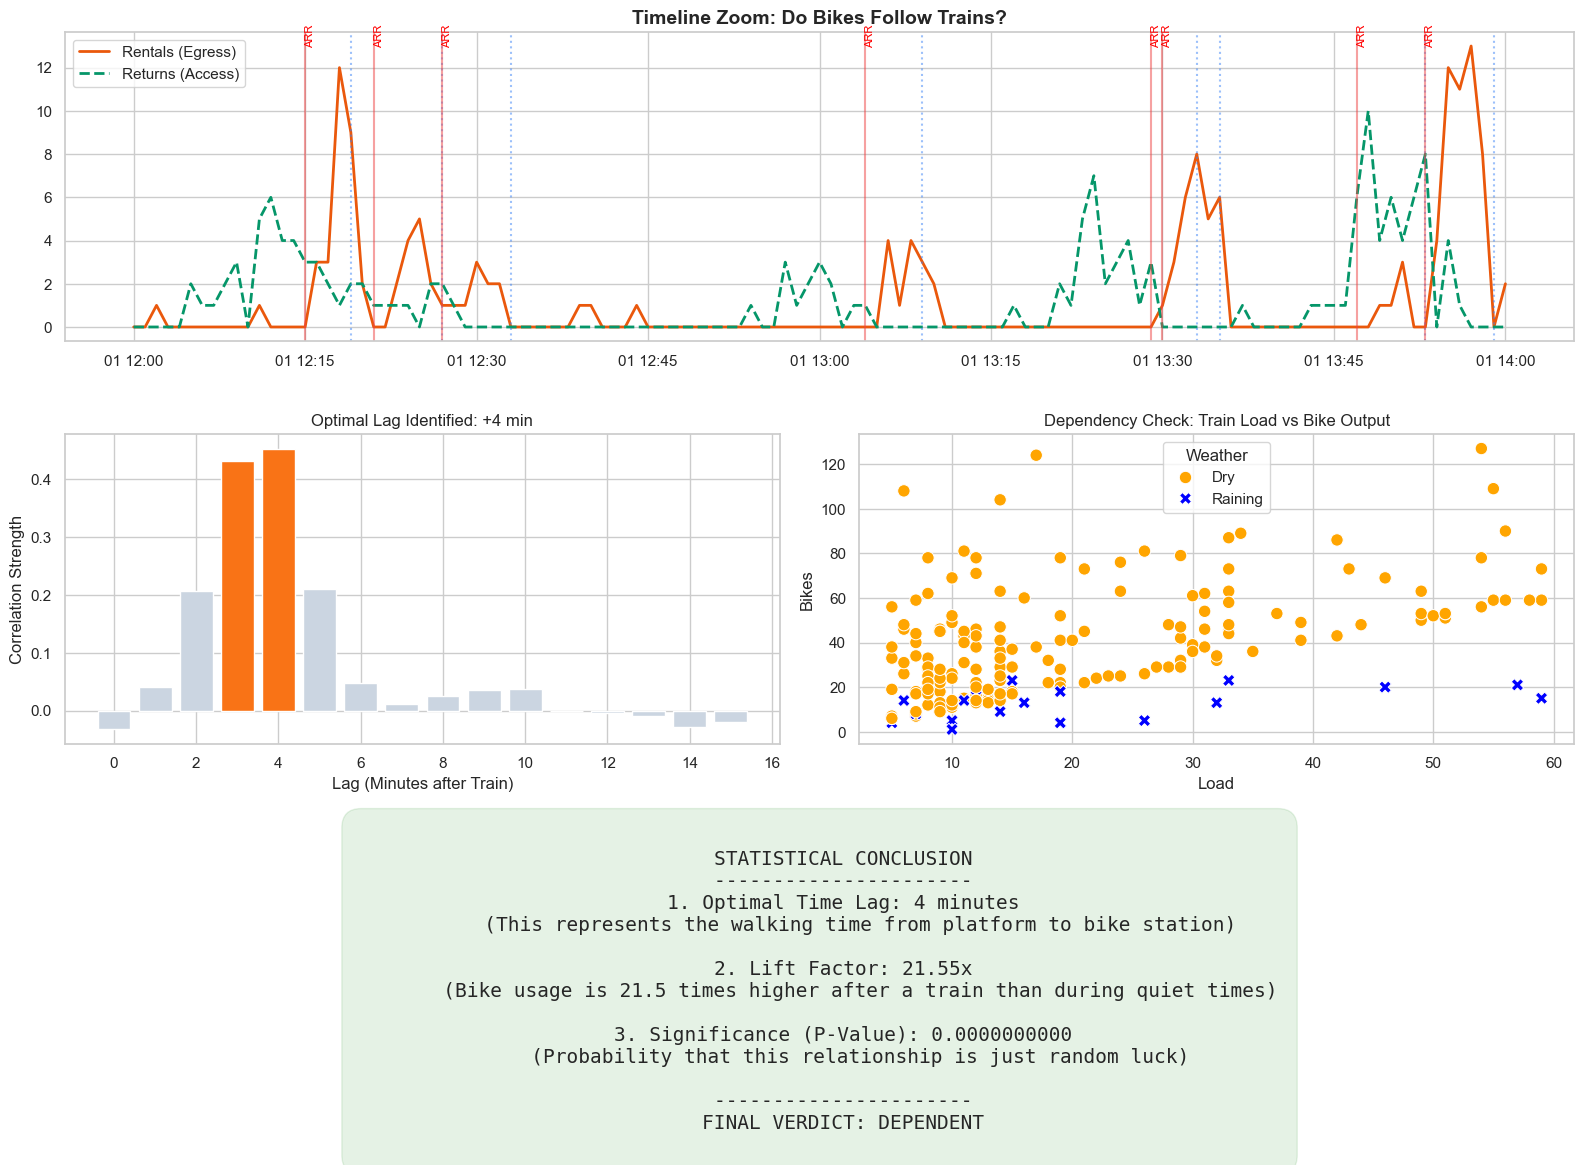

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, pearsonr
from matplotlib.lines import Line2D

# ==========================================
# PART 1: SIMULATION ENGINE (Data Generation)
# ==========================================
def generate_complex_data(hours=48):
    print("1. Generating Train Schedule & Weather...")
    np.random.seed(42) # Reproducible results

    # Timeline
    start = pd.Timestamp("2023-10-01 04:00")
    end = start + pd.Timedelta(hours=hours)
    timeline = pd.date_range(start, end, freq="1min")

    # --- A. Weather Generation ---
    df = pd.DataFrame(index=timeline)
    # Temp: Sine wave (Day/Night)
    hour_float = df.index.hour + df.index.minute/60
    df['Temp'] = 15 + 5*np.sin((hour_float-10)*np.pi/12)

    # Rain Event: Hours 28 to 32 (suppresses bike usage)
    df['Rain_Factor'] = 1.0 # 1.0 = Dry
    rain_mask = (df.index.hour + (df.index.day-1)*24 >= 28) & \
                (df.index.hour + (df.index.day-1)*24 < 32)
    df.loc[rain_mask, 'Rain_Factor'] = 0.2 # 80% suppression

    # --- B. Train Schedule Generation ---
    trains = []
    # Approx 4 trains/hour (Poisson distribution)
    num_trains_per_hour = np.random.poisson(4, hours)

    for h in range(hours):
        n = num_trains_per_hour[h]
        for _ in range(n):
            # Random minute
            offset = np.random.randint(0, 60)
            arr_dt = start + pd.Timedelta(hours=h, minutes=offset)

            # Dwell time (2-8 mins)
            dwell = np.random.randint(2, 8)
            dep_dt = arr_dt + pd.Timedelta(minutes=dwell)

            # Category & Passenger Load
            cat = np.random.choice(['Os', 'R', 'Ex'], p=[0.5, 0.3, 0.2])
            # Load: Random people count based on category
            if cat == 'Os': load = np.random.randint(5, 15)
            elif cat == 'R': load = np.random.randint(15, 35)
            else: load = np.random.randint(30, 60)

            trains.append({
                'Category': cat,
                'Arrival_DT': arr_dt,
                'Departure_DT': dep_dt,
                'Load': load
            })

    train_df = pd.DataFrame(trains).sort_values('Arrival_DT')

    # --- C. Passenger Physics (Gaussian Convolution) ---
    print("2. Simulating Passenger Waves (Gaussian Physics)...")
    df['Sim_Rentals'] = 0.0 # Egress
    df['Sim_Returns'] = 0.0 # Access

    for _, t in train_df.iterrows():
        load = t['Load']

        # 1. ARRIVAL (Rentals): 1 to 6 mins after arrival (Peak ~3.5)
        # We model this as Normal Dist(loc=3.5, scale=1.2)
        delays = norm.rvs(loc=3.5, scale=1.2, size=load)

        for d in delays:
            # Ensure within 1-10 min bounds mostly
            if d < 1: d = 1

            event_time = t['Arrival_DT'] + pd.Timedelta(minutes=d)
            t_idx = event_time.round('min')

            if t_idx in df.index:
                # Apply Weather suppression
                if np.random.random() < df.at[t_idx, 'Rain_Factor']:
                    df.at[t_idx, 'Sim_Rentals'] += 1

        # 2. DEPARTURE (Returns): 15 to 3 mins before departure (Peak ~-9)
        # Normal Dist(loc=-9, scale=2.5)
        earliness = norm.rvs(loc=-9, scale=2.5, size=load)

        for e in earliness:
            event_time = t['Departure_DT'] + pd.Timedelta(minutes=e)
            t_idx = event_time.round('min')

            if t_idx in df.index:
                if np.random.random() < df.at[t_idx, 'Rain_Factor']:
                    df.at[t_idx, 'Sim_Returns'] += 1

    # Add random background noise (non-commuters)
    df['Sim_Rentals'] += np.random.poisson(0.1, len(df))

    return df, train_df

# ==========================================
# PART 2: STATISTICAL DEPENDENCY ENGINE
# ==========================================
def calculate_stats(df, train_df):
    print("3. Calculating Statistical Proof...")

    # --- A. Determine Optimal Lag ---
    # Create discrete signal for train arrivals
    train_signal = pd.Series(0, index=df.index)
    for t in train_df['Arrival_DT']:
        t_idx = t.round('min')
        if t_idx in train_signal.index:
            train_signal[t_idx] = 1 # Binary signal

    # Check Lags 0 to 15
    lags = range(0, 16)
    corrs = []
    for lag in lags:
        # Shift trains forward to predict bikes
        shifted = train_signal.shift(lag).fillna(0)
        corr, _ = pearsonr(shifted, df['Sim_Rentals'])
        corrs.append(corr)

    optimal_lag = lags[np.argmax(corrs)]
    max_corr = max(corrs)

    # --- B. T-Test (Active vs Quiet Windows) ---
    is_active = pd.Series(False, index=df.index)

    # Define active window as Peak Lag +/- 2 mins
    win_start = max(0, optimal_lag - 2)
    win_end = optimal_lag + 3

    for t in train_df['Arrival_DT']:
        s = t + pd.Timedelta(minutes=win_start)
        e = t + pd.Timedelta(minutes=win_end)
        is_active[s:e] = True

    active_data = df.loc[is_active, 'Sim_Rentals']
    quiet_data = df.loc[~is_active, 'Sim_Rentals']

    t_stat, p_val = stats.ttest_ind(active_data, quiet_data, equal_var=False)
    lift = active_data.mean() / quiet_data.mean()

    return {
        'optimal_lag': optimal_lag,
        'max_corr': max_corr,
        'p_value': p_val,
        'lift': lift,
        'lags': lags,
        'corrs': corrs
    }

# ==========================================
# PART 3: VISUALIZATION ENGINE
# ==========================================
def visualize_results(df, train_df, stats_res):
    print("4. Generating Report Charts...")
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2)

    # --- PLOT 1: TIMELINE ZOOM ---
    ax1 = fig.add_subplot(gs[0, :])
    # Zoom to a busy 2-hour window (Hour 8 to 10)
    zoom_start = df.index[0] + pd.Timedelta(hours=8)
    zoom_end = zoom_start + pd.Timedelta(hours=2)
    sub = df[zoom_start:zoom_end]
    sub_t = train_df[(train_df['Arrival_DT'] >= zoom_start) & (train_df['Arrival_DT'] <= zoom_end)]

    ax1.plot(sub.index, sub['Sim_Rentals'], color='#EA580C', lw=2, label='Rentals (Egress)')
    ax1.plot(sub.index, sub['Sim_Returns'], color='#059669', lw=2, ls='--', label='Returns (Access)')

    # Draw Events
    for _, t in sub_t.iterrows():
        # Arrival
        ax1.axvline(t['Arrival_DT'], color='#EF4444', alpha=0.5)
        ax1.text(t['Arrival_DT'], sub['Sim_Rentals'].max(), "ARR", rotation=90, color='red', fontsize=8)
        # Departure
        ax1.axvline(t['Departure_DT'], color='#3B82F6', alpha=0.5, ls=':')

    ax1.set_title("Timeline Zoom: Do Bikes Follow Trains?", fontsize=14, weight='bold')
    ax1.legend()

    # --- PLOT 2: LAG CORRELATION ---
    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['#CBD5E1' if c < 0.8*stats_res['max_corr'] else '#F97316' for c in stats_res['corrs']]
    ax2.bar(stats_res['lags'], stats_res['corrs'], color=colors)
    ax2.set_xlabel("Lag (Minutes after Train)")
    ax2.set_ylabel("Correlation Strength")
    ax2.set_title(f"Optimal Lag Identified: +{stats_res['optimal_lag']} min")

    # --- PLOT 3: WEATHER IMPACT SCATTER ---
    ax3 = fig.add_subplot(gs[1, 1])

    # Aggregate to events
    impact_data = []
    for _, t in train_df.iterrows():
        w_start = t['Arrival_DT']
        w_end = w_start + pd.Timedelta(minutes=15)
        try:
            bikes = df.loc[w_start:w_end, 'Sim_Rentals'].sum()
            is_rain = df.at[w_start.round('min'), 'Rain_Factor'] < 0.5
            impact_data.append({'Load': t['Load'], 'Bikes': bikes, 'Weather': 'Raining' if is_rain else 'Dry'})
        except: pass

    imp_df = pd.DataFrame(impact_data)
    sns.scatterplot(data=imp_df, x='Load', y='Bikes', hue='Weather', style='Weather', s=80, ax=ax3, palette={'Dry':'orange', 'Raining':'blue'})
    ax3.set_title("Dependency Check: Train Load vs Bike Output")

    # --- PLOT 4: STATISTICAL SUMMARY CARD ---
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')

    # Determine verdict
    is_sig = stats_res['p_value'] < 0.05
    verdict = "DEPENDENT" if is_sig else "INDEPENDENT"
    color = "green" if is_sig else "red"

    text = f"""
    STATISTICAL CONCLUSION
    ----------------------
    1. Optimal Time Lag: {stats_res['optimal_lag']} minutes
       (This represents the walking time from platform to bike station)

    2. Lift Factor: {stats_res['lift']:.2f}x
       (Bike usage is {stats_res['lift']:.1f} times higher after a train than during quiet times)

    3. Significance (P-Value): {stats_res['p_value']:.10f}
       (Probability that this relationship is just random luck)

    ----------------------
    FINAL VERDICT: {verdict}
    """

    ax4.text(0.5, 0.5, text, ha='center', va='center', fontsize=14, family='monospace',
             bbox=dict(boxstyle="round,pad=1", fc=color, alpha=0.1, ec=color))

    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Generate
    df_sim, df_train = generate_complex_data(hours=48)

    # 2. Calculate
    stats_results = calculate_stats(df_sim, df_train)

    # 3. Visualize
    visualize_results(df_sim, df_train, stats_results)

In [1]:
import pandas as pd

# CONFIG
FILE_WEATHER = 'data/Ostrava_pocasi.xlsx' # Verify path
RAIN_THRESHOLD = 0.2

print(f"--- DIAGNOSTIC: CHECKING ISO DATE & RAIN ---")

try:
    # 1. Load File
    df = pd.read_excel(FILE_WEATHER)
    df.columns = [str(c).lower().strip() for c in df.columns]

    # 2. Identify Columns
    t_col = next((c for c in df.columns if any(x in c for x in ['date','time','datum','cas'])), None)
    p_col = next((c for c in df.columns if any(x in c for x in ['rain','precip','sraz','uhrn'])), None)

    print(f"Found Time Column: {t_col}")
    print(f"Found Rain Column: {p_col}")

    # 3. Parse ISO Date (Critical Step)
    # forcing standard ISO parsing
    df['clean_ts'] = pd.to_datetime(df[t_col], format='mixed', errors='coerce')

    # 4. Parse Rain (Comma Fix)
    df['clean_rain'] = df[p_col].astype(str).str.replace(',', '.', regex=False)
    df['clean_rain'] = pd.to_numeric(df['clean_rain'], errors='coerce').fillna(0)

    # 5. Check Results
    print("\n--- DATA PREVIEW ---")
    print(df[[t_col, 'clean_ts', p_col, 'clean_rain']].head())

    # 6. Count Rainy Hours
    rainy = df[df['clean_rain'] > RAIN_THRESHOLD]
    print(f"\nTotal Rainy Hours (> {RAIN_THRESHOLD}mm): {len(rainy)}")

    if len(rainy) > 0:
        print("Sample Rainy Event:")
        print(rainy.iloc[0])
    else:
        print("❌ WARNING: No rain detected. Check threshold or decimal parsing.")

except Exception as e:
    print(f"❌ ERROR: {e}")

--- DIAGNOSTIC: CHECKING ISO DATE & RAIN ---


C:\Users\vaclavikmartin\PycharmProjects\Nextbike\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Found Time Column: datetime
Found Rain Column: precip

--- DATA PREVIEW ---
              datetime            clean_ts  precip  clean_rain
0  2025-09-15T00:00:00 2025-09-15 00:00:00     0.0         0.0
1  2025-09-15T01:00:00 2025-09-15 01:00:00     0.0         0.0
2  2025-09-15T02:00:00 2025-09-15 02:00:00     0.0         0.0
3  2025-09-15T03:00:00 2025-09-15 03:00:00     0.0         0.0
4  2025-09-15T04:00:00 2025-09-15 04:00:00     0.0         0.0

Total Rainy Hours (> 0.2mm): 124
Sample Rainy Event:
name                                                          Ostrava
datetime                                          2025-09-15T16:00:00
temp                                                             18.5
feelslike                                                        18.5
dew                                                              14.3
humidity                                                        76.83
precip                                                          0.258
pr